In [40]:
	
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
data = pd.read_csv('/Users/sharvitkashikar/Training-june/day7/ecosystem_data.csv')
data

,water_quality,air_quality_index,biodiversity_index,vegetation_cover,soil_ph,ecosystem_health
0,37.454012,112.092246,0.729998,63.814457,5.144016,degraded
1,95.071431,99.873629,0.184512,45.929245,4.021498,degraded
2,73.199394,52.846174,0.346640,96.449852,4.194976,degraded
3,59.865848,182.180001,0.663281,21.897845,4.493691,degraded
4,15.601864,142.987248,0.482089,58.785642,4.620093,degraded
...,...,...,...,...,...,...
9995,85.765599,263.111589,0.952275,75.403391,6.923449,degraded
9996,89.750884,14.044187,0.747824,76.452694,4.744065,at risk
9997,94.670792,91.109541,0.019456,26.956943,7.619473,degraded
9998,39.748799,132.996002,0.401005,43.431977,6.365560,degraded


In [42]:
data['ecosystem_health'].unique()

array(['degraded', 'at risk', 'healthy'], dtype=object)

In [43]:
data['ecosystem_health'] = data['ecosystem_health'].map({'healthy': 1, 'at risk': 0, 'degraded': 2})
data

,water_quality,air_quality_index,biodiversity_index,vegetation_cover,soil_ph,ecosystem_health
0,37.454012,112.092246,0.729998,63.814457,5.144016,2
1,95.071431,99.873629,0.184512,45.929245,4.021498,2
2,73.199394,52.846174,0.346640,96.449852,4.194976,2
3,59.865848,182.180001,0.663281,21.897845,4.493691,2
4,15.601864,142.987248,0.482089,58.785642,4.620093,2
...,...,...,...,...,...,...
9995,85.765599,263.111589,0.952275,75.403391,6.923449,2
9996,89.750884,14.044187,0.747824,76.452694,4.744065,0
9997,94.670792,91.109541,0.019456,26.956943,7.619473,2
9998,39.748799,132.996002,0.401005,43.431977,6.365560,2


In [44]:
X = data[['water_quality','air_quality_index','biodiversity_index','vegetation_cover','soil_ph']]
y = data['ecosystem_health']
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
gnb = GaussianNB()
# Train the classifier
gnb.fit(X_train, y_train)
# Make predictions on the test set
y_pred = gnb.predict(X_test)
# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 95.15%


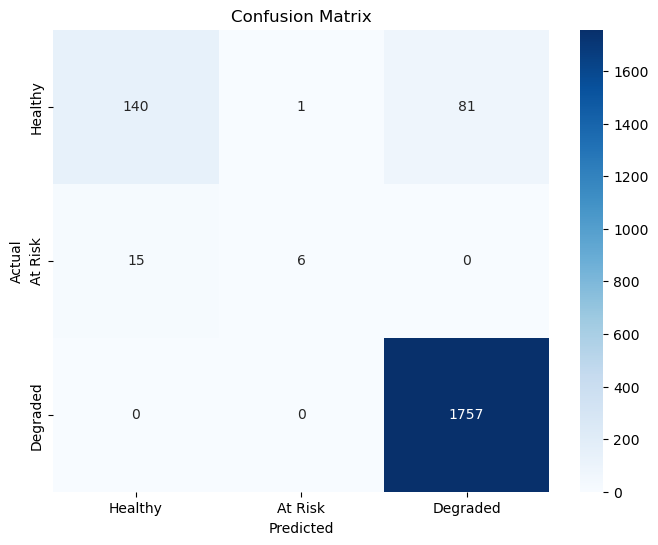

In [46]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'At Risk', 'Degraded'], yticklabels=['Healthy', 'At Risk', 'Degraded'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [47]:
import joblib
joblib.dump(gnb, 'ecosystem_health_model.pkl')

['ecosystem_health_model.pkl']

In [49]:
wq = float(input("Enter water quality index: "))
aqi = float(input("Enter air quality index: "))
biodiversity = float(input("Enter biodiversity index: "))
veg_cover = float(input("Enter vegetation cover index: "))
soil_ph = float(input("Enter soil pH index: "))
# Predict the ecosystem health based on user input
user_input = np.array([[wq, aqi, biodiversity, veg_cover, soil_ph]])
predicted_health = gnb.predict(user_input)
print("Predicted Ecosystem Health:")
if predicted_health == 1:
    print("Healthy")
elif predicted_health == 0:
    print("At Risk")
elif predicted_health == 2:
    print("Degraded")
    

Predicted Ecosystem Health:
Degraded


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [53]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority')
X,y = smote.fit_resample(X,y)
y.value_counts()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


ecosystem_health
2    8761
0    8761
1    8761
Name: count, dtype: int64